In [1]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from notebooks import config 

In [ ]:
PREFIX_MAP = {'l5': 'Landsat-5', 'l7': 'Landsat-7', 'l8': 'Landsat-8','l9': 'Landsat-9', 's2': 'Sentinel-2'}
COLORS_SAT = ['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#ccb974', '#64b5cd']
COLORS_WAT = ['#3498db', '#95a5a6']
TEXT_STYLE = {'color': 'white', 'weight': 'bold'}
WEDGE_STYLE = {'edgecolor': 'white'}
plt.rcParams.update({'font.family': 'Arial', 'font.size': 10})


In [ ]:
pixels = Counter()
scenes = Counter()
water_stats = {"Water": 0, "Non-water": 0}

print("开始处理影像数据并统计...")

for path in config.paths_truth:
    basename = os.path.basename(path).lower()
    
    sat_type = 'Other'
    for prefix, name in PREFIX_MAP.items():
        if basename.startswith(prefix):
            sat_type = name
            break
            
    scenes[sat_type] += 1        
    
    try:
        with rasterio.open(path) as src:
            pixels[sat_type] += src.width * src.height
            lbl = src.read(1)                
            
            w_count = np.count_nonzero(lbl == 1) 
            water_stats["Water"] += w_count
            water_stats["Non-water"] += lbl.size - w_count
            
    except Exception as e:
        print(f"[跳过] {basename}: {e}")

sat_keys = sorted(pixels.keys())
pixel_values = [pixels[k] for k in sat_keys]
scene_values = [scenes[k] for k in sat_keys]
total_scenes = sum(scene_values)


开始处理影像数据并统计...


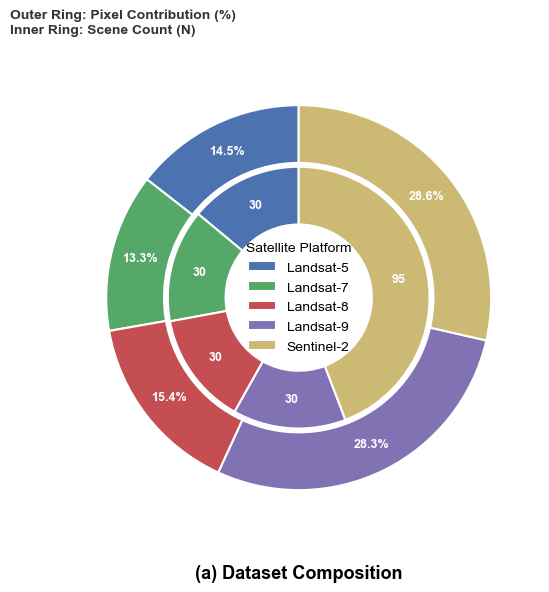

In [ ]:
# 绘制图表 A - 数据集构成 (双环图)
fig_a, ax_a = plt.subplots(figsize=(6, 6))

w_out, _, _ = ax_a.pie(
    pixel_values, radius=1.0, 
    colors=COLORS_SAT, 
    startangle=90,
    autopct='%1.1f%%', 
    pctdistance=0.85, 
    textprops={**TEXT_STYLE, 'size': 9}, 
    wedgeprops={**WEDGE_STYLE, 'width': 0.3, 'linewidth': 1.5}
)

ax_a.pie(
    scene_values, 
    radius=0.68, 
    colors=COLORS_SAT, 
    startangle=90,
    autopct=lambda p: f"{int(round(p * total_scenes / 100))}", 
    pctdistance=0.78, 
    textprops={**TEXT_STYLE, 'size': 9}, 
    wedgeprops={**WEDGE_STYLE, 'width': 0.3, 'linewidth': 1.5}
)

ax_a.legend(w_out, sat_keys, title="Satellite Platform", loc="center", frameon=False)
ax_a.text(
    -0.1, 1.05, 
    "Outer Ring: Pixel Contribution (%)\nInner Ring: Scene Count (N)", 
    transform=ax_a.transAxes,
    fontsize=10, 
    fontweight='bold', 
    color='#333333'
)
ax_a.set_title("(a) Dataset Composition", y=-0.1, fontweight='bold', size=13)

plt.tight_layout()
# plt.savefig('figs/Dataset Composition.png', dpi=300, bbox_inches='tight')
plt.show()


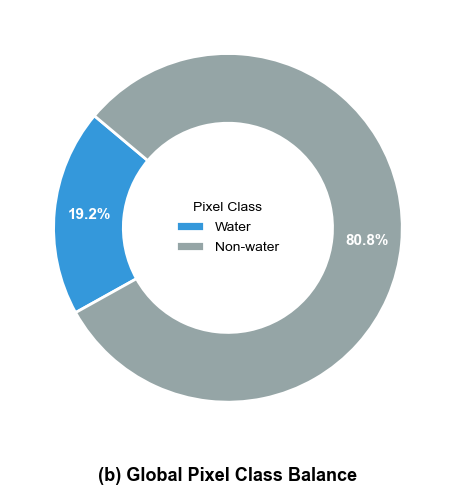

In [ ]:
# 绘制图表 B - 水体像素平衡 (单环图)
fig_b, ax_b = plt.subplots(figsize=(5, 5))
w_wat, _, _ = ax_b.pie(
    list(water_stats.values()), 
    radius=1.0, 
    colors=COLORS_WAT, 
    startangle=140,
    autopct='%1.1f%%', 
    pctdistance=0.8, 
    textprops={**TEXT_STYLE, 'size': 11}, 
    wedgeprops={**WEDGE_STYLE, 'width': 0.4, 'linewidth': 2}
)

ax_b.legend(w_wat, list(water_stats.keys()), title="Pixel Class", loc="center", frameon=False)
ax_b.set_title("(b) Global Pixel Class Balance", y=-0.1, fontweight='bold', size=13)

plt.tight_layout()
# plt.savefig('figs/Global Pixel Class Balance.png', dpi=300, bbox_inches='tight')
plt.show()
